In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. 初期パラメータ設定 (Experiment Configurations)
# =====================================================================
# [モデル設定]
N = 40                  # 変数の数 (観測の数 P も今回は同じ40)
F = 8.0                 # 強制項
dt = 0.01               # 積分時間ステップ
sampling_dt = 0.05      # 観測・同化の間隔 (6時間相当: 0.25日/5日)
m = 8                   # アンサンブルメンバー数

# [時間設定]
years = 2
units_per_year = 73.0   # 1年 = 365日 / 5日 = 73ユニット
total_time = years * units_per_year
spin_up_time = units_per_year

steps_total = int(total_time / dt)
steps_spin_up = int(spin_up_time / dt)
sampling_interval = int(sampling_dt / dt)

# [データ同化設定]
H_mat = np.eye(N)                       # 観測演算子 H (全点観測)
R_mat = np.eye(N)                       # 観測誤差共分散 R (対角成分1)

In [2]:
# =====================================================================
# 2. Nature Run (真値) と Observation (観測) の生成 (kadai5準拠)
# =====================================================================

def lorenz96(x, F):
    # x の shape が (N,) でも (N, m) でも、axis=0で一括計算
    return (np.roll(x, -1, axis=0) - np.roll(x, 2, axis=0)) * np.roll(x, 1, axis=0) - x + F

def M(x_in, dt, steps):
    # ルンゲ・クッタ法も全メンバーを並列一括処理
    x_out = x_in.copy()
    for _ in range(steps):
        k1 = lorenz96(x_out, F)
        k2 = lorenz96(x_out + k1 * (dt / 2.0), F)
        k3 = lorenz96(x_out + k2 * (dt / 2.0), F)
        k4 = lorenz96(x_out + k3 * dt, F)
        x_out += (k1 + 2.0*k2 + 2.0*k3 + k4) * (dt / 6.0)
    return x_out

print("Nature Runと観測データを生成中...")
x = np.full(N, F)
x[19] += 0.001 # カオス誘発用の摂動

true_states = []
for s in range(steps_total):
    x = M(x, dt, 1)  # dtステップで1回の積分
    if s >= steps_spin_up and (s - steps_spin_up) % sampling_interval == 0:
        true_states.append(x.copy())
true_states = np.array(true_states)

# [変更点] モダンな乱数生成器 (default_rng) を使用
rng_obs = np.random.default_rng(seed=92) 
noise = rng_obs.standard_normal(size=true_states.shape)
#noise -= np.mean(noise, axis=0)  # 各変数ごとに平均0に調整
y_o_data = true_states + noise # 観測データ y^o

print("生成完了！")

Nature Runと観測データを生成中...
生成完了！


Serial EnSRF (Fast) を実行中... (delta=0.03, sigma=4.5)
実行完了！



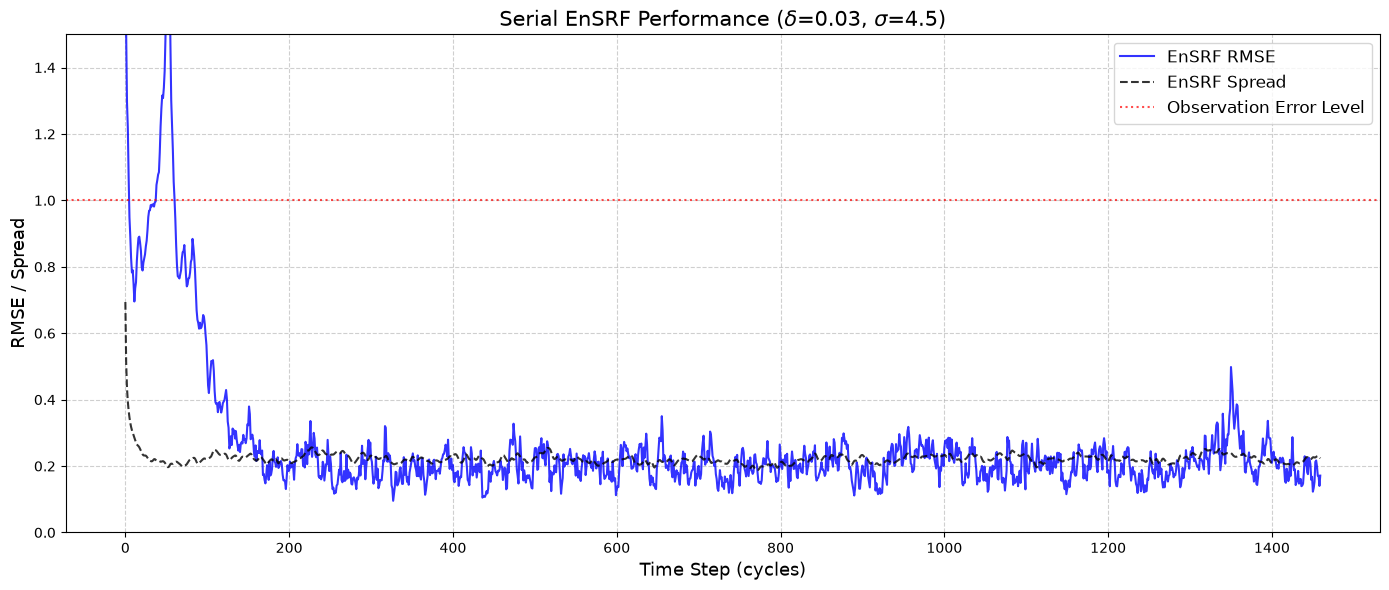

【初期 140 サイクル除外後の平均値】
Average RMSE         : 0.2048
Average Spread       : 0.2212
RMSE/Spread Ratio    : 0.9253


In [ ]:
# =====================================================================
# 6. 高速化版 EnSRF (Matrix-Vector分解による O(Nm) 実装)
# =====================================================================
def Gaspari_Cohn_L(sigma):
    L = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            d = min(abs(i - j), N - abs(i - j))
            r = d / (np.sqrt(10 / 3) * sigma)
            if r <= 1.0:
                val = 1 - 1/4 * r**5 + 1/2 * r**4 + 5/8 * r**3 - 5/3 * r**2
            elif r <= 2.0:
                val = 1/12 * r**5 - 1/2 * r**4 + 5/8 * r**3 + 5/3 * r**2 - 5 * r + 4 - 2/3 * (1/r)
            else:
                val = 0.0
            L[i, j] = val
    return L

def run_EnSRF_fast(y_o_data, true_states_input, delta, sigma):
    """
    Serial EnSRFの高速化版。
    Pbを直接計算せず、Pb * hi^T = Zb * (Zb^T * hi^T) として計算することで
    計算量を O(N^2 * m) から O(N * m) に削減。
    """
    num_cycles = y_o_data.shape[0]
    num_obs = H_mat.shape[0]
    
    # 局所化行列の事前計算
    L_mat = Gaspari_Cohn_L(sigma)
    
    # アンサンブル初期化
    rng = np.random.default_rng(seed=123)
    x_raw_init = np.full(N, F)
    x_raw_init[min(19, N-1)] += 1.001
    X_a = M(x_raw_init[:, None] + rng.normal(0, 0.1, (N, m)), dt, steps_spin_up)

    # 時系列プロットのため、リストではなく全サイクル分の配列を用意
    rmse_record = np.zeros(num_cycles)
    spread_record = np.zeros(num_cycles)

    for t in range(num_cycles):
        # 予測
        X_b = M(X_a, dt, sampling_interval)
        x_b_mean = np.mean(X_b, axis=1)
        # 背景摂動のインフレーション適用
        Z_b = (X_b - x_b_mean[:, None]) * (1.0 + delta) / np.sqrt(m - 1)
        
        # 直列同化ループ (ここが最速化のキモ)
        for i in range(num_obs):
            y_o_i = y_o_data[t, i]
            R_i = R_mat[i, i]
            h_i = H_mat[i, :]
            L_i = L_mat[i, :]
            
            # --- Pbを計算せずに Pb * hi.T を求める ---
            # Pb * hi.T = (Zb @ Zb.T) @ hi.T = Zb @ (Zb.T @ hi.T)
            # (N, m) @ (m, 1) -> (N, 1) の計算なので爆速
            v_tmp = Z_b.T @ h_i        # (m,)
            p_h = Z_b @ v_tmp          # (N,)
            hp_h = h_i @ p_h           # scalar (h * Pb * h.T)
            
            V_i = hp_h + R_i
            k_t = p_h / V_i
            alpha = 1.0 / (1.0 + np.sqrt(R_i / V_i))
            k_t_hat = k_t * alpha
            
            # 局所化適用
            K_i = L_i * k_t
            K_i_hat = L_i * k_t_hat
            
            # 更新
            innovation = y_o_i - h_i @ x_b_mean
            x_b_mean += K_i * innovation
            
            # 摂動更新も O(Nm) で実行
            Z_b -= np.outer(K_i_hat, h_i @ Z_b)
            
        # 解析アンサンブルの再構築
        X_a = x_b_mean[:, None] + Z_b * np.sqrt(m - 1)
        
        # 毎サイクルのRMSEとSpreadを記録
        rmse_record[t] = np.sqrt(np.mean((x_b_mean - true_states_input[t])**2))
        spread_record[t] = np.sqrt(np.mean(np.var(X_a, axis=1, ddof=1)))
        
    return rmse_record, spread_record


# =====================================================================
# 実行とRMSE/Spreadのプロット・平均値出力
# =====================================================================
# パラメータ設定 (RMSE=0.20のオアシス付近のパラメータ)
param_delta = 0.03
param_sigma = 4.5

print(f"Serial EnSRF (Fast) を実行中... (delta={param_delta}, sigma={param_sigma})")
rmse_ensrf, spread_ensrf = run_EnSRF_fast(y_o_data, true_states, delta=param_delta, sigma=param_sigma)
print("実行完了！\n")

# --- グラフの描画 ---
plt.figure(figsize=(14, 6))

plt.plot(rmse_ensrf, label='EnSRF RMSE', color='blue', alpha=0.8, linewidth=1.5)
plt.plot(spread_ensrf, label='EnSRF Spread', color='black', linestyle='--', alpha=0.8, linewidth=1.5)

# 観測誤差レベル (R=1.0) のライン
plt.axhline(y=1.0, color='red', linestyle=':', alpha=0.7, label='Observation Error Level')

plt.xlabel('Time Step (cycles)', fontsize=13)
plt.ylabel('RMSE / Spread', fontsize=13)
plt.title(rf'Serial EnSRF Performance ($\delta$={param_delta}, $\sigma$={param_sigma})', fontsize=15)
plt.ylim(0, 1.5)
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

# --- 平均値の出力 (初期スピンアップ50サイクルを除外) ---
spin_up = 140
ave_rmse = np.mean(rmse_ensrf[spin_up:])
ave_spread = np.mean(spread_ensrf[spin_up:])
ave_ratio = np.mean(rmse_ensrf[spin_up:] / spread_ensrf[spin_up:])

print(f"【初期 {spin_up} サイクル除外後の平均値】")
print(f"Average RMSE         : {ave_rmse:.4f}")
print(f"Average Spread       : {ave_spread:.4f}")
print(f"RMSE/Spread Ratio    : {ave_ratio:.4f}")

In [4]:
# =====================================================================
# 4. Serial EnSRFの実行とRMSE・Spreadの時間変化の可視化
# =====================================================================
import matplotlib.pyplot as plt

# パラメータ設定
param_delta = 0.10  # インフレーション係数
param_sigma = 3.0   # 局所化スケール

print("Serial EnSRFを実行中...")
# m はグローバル変数として 40 等が設定されている前提です
rmse_ensrf, spread_ensrf = run_EnSRF(y_o_data, true_states, delta=param_delta, sigma=param_sigma)
print("実行完了！")

# グラフの描画
plt.figure(figsize=(10, 5))

# RMSEとSpreadのプロット
plt.plot(rmse_ensrf, label='EnSRF RMSE', color='blue', alpha=0.8, linewidth=1.5)
plt.plot(spread_ensrf, label='EnSRF Spread', color='black', linestyle='--', alpha=0.8, linewidth=1.5)

# グラフの装飾
plt.xlabel('Time Step (cycles)', fontsize=12)
plt.ylabel('RMSE / Spread', fontsize=12)
plt.title(f'Serial EnSRF Performance ($\delta$={param_delta}, $\sigma$={param_sigma})', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# 描画
plt.show()

print("average RMSE:", np.mean(rmse_ensrf))
print("average Spread:", np.mean(spread_ensrf))
ave_ratio = np.mean(rmse_ensrf / spread_ensrf)
print("average RMSE/Spread ratio:", ave_ratio)

Serial EnSRFを実行中...


<>:25: SyntaxWarning: invalid escape sequence '\d'
<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\d'
<>:25: SyntaxWarning: invalid escape sequence '\s'
C:\Users\hanha\AppData\Local\Temp\ipykernel_5764\2281720602.py:25: SyntaxWarning: invalid escape sequence '\d'
  plt.title(f'Serial EnSRF Performance ($\delta$={param_delta}, $\sigma$={param_sigma})', fontsize=14)
C:\Users\hanha\AppData\Local\Temp\ipykernel_5764\2281720602.py:25: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'Serial EnSRF Performance ($\delta$={param_delta}, $\sigma$={param_sigma})', fontsize=14)


NameError: name 'run_EnSRF' is not defined

In [8]:
# =====================================================================
# 6. 高速化版 EnSRF (Matrix-Vector分解による O(Nm) 実装)
# =====================================================================
import numpy as np

def run_EnSRF_fast(y_o_data, true_states, delta, sigma):
    """
    Serial EnSRFの高速化版。
    Pbを直接計算せず、Pb * hi^T = Zb * (Zb^T * hi^T) として計算することで
    計算量を O(N^2 * m) から O(N * m) に削減。
    """
    num_cycles = y_o_data.shape[0]
    num_obs = H_mat.shape[0]
    
    # 局所化行列の事前計算
    L_mat = Gaspari_Cohn_L(sigma)
    
    # アンサンブル初期化
    rng = np.random.default_rng(seed=42)
    x_raw_init = np.full(N, F)
    x_raw_init[min(19, N-1)] += 1.001
    X_a = M(x_raw_init[:, None] + rng.normal(0, 0.1, (N, m)), dt, steps_spin_up)

    rmse_record = []

    for t in range(num_cycles):
        # 予測
        X_b = M(X_a, dt, sampling_interval)
        x_b_mean = np.mean(X_b, axis=1)
        # 背景摂動のインフレーション適用
        Z_b = (X_b - x_b_mean[:, None]) * (1.0 + delta) / np.sqrt(m - 1)
        
        # 直列同化ループ (ここが最速化のキモ)
        for i in range(num_obs):
            y_o_i = y_o_data[t, i]
            R_i = R_mat[i, i]
            h_i = H_mat[i, :]
            L_i = L_mat[i, :]
            
            # --- Pbを計算せずに Pb * hi.T を求める ---
            # Pb * hi.T = (Zb @ Zb.T) @ hi.T = Zb @ (Zb.T @ hi.T)
            # (N, m) @ (m, 1) -> (N, 1) の計算なので爆速
            v_tmp = Z_b.T @ h_i        # (m,)
            p_h = Z_b @ v_tmp          # (N,)
            hp_h = h_i @ p_h           # scalar (h * Pb * h.T)
            
            V_i = hp_h + R_i
            k_t = p_h / V_i
            alpha = 1.0 / (1.0 + np.sqrt(R_i / V_i))
            k_t_hat = k_t * alpha
            
            # 局所化適用
            K_i = L_i * k_t
            K_i_hat = L_i * k_t_hat
            
            # 更新
            innovation = y_o_i - h_i @ x_b_mean
            x_b_mean += K_i * innovation
            
            # 摂動更新も O(Nm) で実行
            # (I - Ki_hat @ hi) @ Zb = Zb - Ki_hat @ (hi @ Zb)
            Z_b -= np.outer(K_i_hat, h_i @ Z_b)
            
        # 解析アンサンブルの再構築
        X_a = x_b_mean[:, None] + Z_b * np.sqrt(m - 1)
        
        # スピンアップ後のみRMSEを記録
        if t >= 140:
            rmse_record.append(np.sqrt(np.mean((x_b_mean - true_states[t])**2)))
            
    return np.mean(rmse_record)

PCの全コアを使用して、900パターンの並列計算を開始します...
探索完了！ 実行時間: 352.83 秒


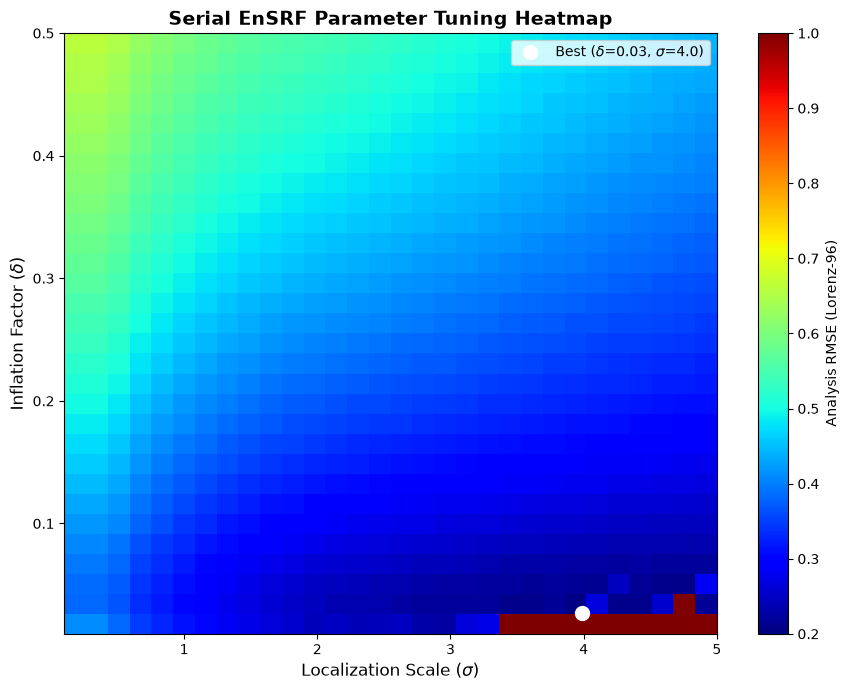

In [9]:
# =====================================================================
# 7. delta と sigma のヒートマップ作成 (ゼロ除算修正・設定輸入版)
# =====================================================================
import numpy as np
import time
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

# 探索範囲の設定 (sigmaが0にならないように 0.1 からスタート)
delta_range = np.linspace(0.01, 0.5, 30)
sigma_range = np.linspace(0.1, 5.0, 30)

# すべての組み合わせのリストを作成 (50 x 50 = 2500通り)
param_grid = [(d, s) for d in delta_range for s in sigma_range]

print(f"PCの全コアを使用して、{len(param_grid)}パターンの並列計算を開始します...")
start_time = time.time()

# --- Joblibによる並列処理 ---
results_flat = Parallel(n_jobs=-1)(
    delayed(run_EnSRF_fast)(y_o_data, true_states, delta=d, sigma=s)
    for d, s in param_grid
)

end_time = time.time()
print(f"探索完了！ 実行時間: {end_time - start_time:.2f} 秒")

# 1次元リストをヒートマップ用の2次元配列 (50x50) に変形
rmse_matrix = np.array(results_flat).reshape(len(delta_range), len(sigma_range))

# --- 安全装置 ---
# NaNや無限大が発生した場合は、発散したとみなして上限値(1.0)に置換
rmse_matrix = np.nan_to_num(rmse_matrix, nan=1.0, posinf=1.0, neginf=1.0)
# RMSEが1.0より大きい無価値な領域を1.0に丸める
rmse_matrix = np.where(rmse_matrix > 1.0, 1.0, rmse_matrix)

# --- 可視化 (LETKFコードからの設定輸入) ---
plt.figure(figsize=(9, 7), dpi=100)

# origin='lower' で delta が下から上へ増加するように配置
img = plt.imshow(rmse_matrix, 
                 extent=[sigma_range[0], sigma_range[-1], delta_range[0], delta_range[-1]], 
                 origin='lower', 
                 aspect='auto', 
                 cmap='jet', 
                 vmin=0.2, 
                 vmax=1.0)

plt.colorbar(img, label='Analysis RMSE (Lorenz-96)')
plt.xlabel(r'Localization Scale ($\sigma$)', fontsize=12)
plt.ylabel(r'Inflation Factor ($\delta$)', fontsize=12)
plt.title('Serial EnSRF Parameter Tuning Heatmap', fontsize=14, fontweight='bold')

# 最適値のプロット
min_idx = np.unravel_index(np.argmin(rmse_matrix), rmse_matrix.shape)
best_sigma = sigma_range[min_idx[1]]
best_delta = delta_range[min_idx[0]]
plt.plot(best_sigma, best_delta, 'wo', markersize=10, label=f'Best ($\\delta$={best_delta:.2f}, $\\sigma$={best_sigma:.1f})')
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
print(f"最適パラメータ: delta = {best_delta:.2f}, sigma = {best_sigma:.1f}, 最小RMSE = {rmse_matrix[min_idx]:.4f}")

最適パラメータ: delta = 0.03, sigma = 4.0, 最小RMSE = 0.2060


In [ ]:
# =====================================================================
# 7. delta と sigma のヒートマップ作成 (計算ロジック適応・配色設定輸入版)
# =====================================================================
import numpy as np
import time
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

# --- 1. ユーザーの計算ロジックを反映させた高速化EnSRF関数 ---
def run_EnSRF_fast_user_logic(y_o_data, true_states_input, delta, sigma):
    num_cycles = y_o_data.shape[0]
    num_obs = H_mat.shape[0]
    L_matrix = Gaspari_Cohn_L(sigma)
    
    rng = np.random.default_rng(seed=42)
    x_raw_init = np.full(N, F)
    x_raw_init[min(19, N-1)] += 0.001
    X_a = M(x_raw_init[:, None] + rng.normal(0, 0.1, (N, m)), dt, steps_spin_up)

    rmse_record = np.zeros(num_cycles)

    for t in range(num_cycles):
        X_b = M(X_a, dt, sampling_interval)
        
        # インフレーション: curr_X_forecast + inflation * (curr_X_forecast - mean)
        x_b_mean_inf = np.mean(X_b, axis=1, keepdims=True)
        X_b = X_b + delta * (X_b - x_b_mean_inf)
        
        # 平均と摂動の分離
        x_mean = np.mean(X_b, axis=1, keepdims=True)
        Z_background = X_b - x_mean
        
        # 逐次同化ループ
        for i in range(num_obs):
            y_o_i = y_o_data[t, i]
            H_i = H_mat[i:i+1, :]  # 1xN matrix
            R_i = R_mat[i, i]
            
            Y_background = H_i @ Z_background
            L_loc = L_matrix[:, i:i+1] # Nx1 matrix
            
            # 分散共分散の計算 (m-1で割る方式)
            Pb_HT = L_loc * (Z_background @ Y_background.T) / (m - 1)
            H_Pb_HT = (Y_background @ Y_background.T) / (m - 1)
            
            # カルマンゲイン
            K = Pb_HT / (H_Pb_HT + R_i)
            K_tilde = K * (1.0 / (1.0 + np.sqrt(R_i / (H_Pb_HT + R_i))))
            
            # 平均と摂動を個別に更新
            x_mean = x_mean + K * (y_o_i - H_i @ x_mean)
            Z_background = Z_background - K_tilde @ Y_background
            
        # 全観測の同化終了後に合体
        X_a = Z_background + x_mean
        
        # 1次元配列に戻してRMSEを記録
        rmse_record[t] = np.sqrt(np.mean((np.squeeze(x_mean) - true_states_input[t])**2))
        
    # スピンアップ(初期50サイクル)を除外した平均RMSEを返す
    return np.mean(rmse_record[50:])

# --- 2. ヒートマップの並列探索 ---
# 探索範囲の設定 (sigmaが0にならないように0.1から)
delta_range = np.linspace(0.01, 1.00, 30)
sigma_range = np.linspace(0.1, 10.0, 30)

# すべての組み合わせのリストを作成 (50 x 50 = 2500通り)
param_grid = [(d, s) for d in delta_range for s in sigma_range]

print(f"PCの全コアを使用して、{len(param_grid)}パターンの並列計算を開始します...")
start_time = time.time()

# Joblibによる並列処理
results_flat = Parallel(n_jobs=-1)(
    delayed(run_EnSRF_fast_user_logic)(y_o_data, true_states, delta=d, sigma=s)
    for d, s in param_grid
)

end_time = time.time()
print(f"探索完了！ 実行時間: {end_time - start_time:.2f} 秒")

# --- 3. データの整形と安全装置 ---
# 1次元リストをヒートマップ用の2次元配列に変形
rmse_matrix = np.array(results_flat).reshape(len(delta_range), len(sigma_range))

# NaNや無限大が発生した場合は、発散したとみなして上限値(1.0)に置換
rmse_matrix = np.nan_to_num(rmse_matrix, nan=1.0, posinf=1.0, neginf=1.0)
# RMSEが1.0より大きい無価値な領域を1.0に丸める
rmse_matrix = np.where(rmse_matrix > 1.0, 1.0, rmse_matrix)

# --- 4. 可視化 ---
plt.figure(figsize=(9, 7), dpi=100)

# origin='lower' で delta が下から上へ増加するように配置
img = plt.imshow(rmse_matrix, 
                 extent=[sigma_range[0], sigma_range[-1], delta_range[0], delta_range[-1]], 
                 origin='lower', 
                 aspect='auto', 
                 cmap='jet', 
                 vmin=0.2, 
                 vmax=1.0)

plt.colorbar(img, label='Analysis RMSE (Lorenz-96)')
plt.xlabel(r'Localization Scale ($\sigma$)', fontsize=12)
plt.ylabel(r'Inflation Factor ($\delta$)', fontsize=12)
plt.title('Serial EnSRF Parameter Tuning Heatmap', fontsize=14, fontweight='bold')

# 最適値のプロット (RMSEが最小となるインデックスを取得)
min_idx = np.unravel_index(np.argmin(rmse_matrix), rmse_matrix.shape)
best_sigma = sigma_range[min_idx[1]]
best_delta = delta_range[min_idx[0]]
plt.plot(best_sigma, best_delta, 'wo', markersize=10, label=f'Best ($\\delta$={best_delta:.2f}, $\\sigma$={best_sigma:.1f})')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
print(f"最適パラメータ: delta = {best_delta:.2f}, sigma = {best_sigma:.1f}, 最小RMSE = {rmse_matrix[min_idx]:.4f}")

In [ ]:
# =====================================================================
# ヒートマップ作成: 観測点数20 (Homogeneous vs Dense) 高解像度版
# =====================================================================
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time
from joblib import Parallel, delayed

# --- 1. すでに生成済みの true_states を利用して部分観測データを作成 ---
actual_cycles = len(true_states)
num_obs_partial = 20

# パターンA: Homogeneous (均等配置: 0, 2, 4, ..., 38)
obs_indices_homo = np.arange(0, N, 2)
H_homo = np.zeros((num_obs_partial, N))
for i, idx in enumerate(obs_indices_homo):
    H_homo[i, idx] = 1.0

# パターンB: Dense (局所集中配置: 0, 1, 2, ..., 19)
obs_indices_dense = np.arange(0, num_obs_partial)
H_dense = np.zeros((num_obs_partial, N))
for i, idx in enumerate(obs_indices_dense):
    H_dense[i, idx] = 1.0

R_partial = np.eye(num_obs_partial)
rng_obs_partial = np.random.default_rng(seed=123)

# 既存の真値 (true_states) に観測行列 H を掛けてノイズを足す
y_o_data_homo = (true_states @ H_homo.T) + rng_obs_partial.normal(0, 1.0, (actual_cycles, num_obs_partial))
y_o_data_dense = (true_states @ H_dense.T) + rng_obs_partial.normal(0, 1.0, (actual_cycles, num_obs_partial))

print(f"部分観測用データ生成完了! (同化サイクル数: {actual_cycles})")

# --- 2. 局所化関数 ---
def Gaspari_Cohn_L(sigma):
    L = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            d = min(abs(i - j), N - abs(i - j))
            r = d / (np.sqrt(10 / 3) * sigma)
            if r <= 1.0:
                val = 1 - 1/4 * r**5 + 1/2 * r**4 + 5/8 * r**3 - 5/3 * r**2
            elif r <= 2.0:
                val = 1/12 * r**5 - 1/2 * r**4 + 5/8 * r**3 + 5/3 * r**2 - 5 * r + 4 - 2/3 * (1/r)
            else:
                val = 0.0
            L[i, j] = val
    return L

# --- 3. 部分観測対応の高速化EnSRF関数 ---
def run_EnSRF_fast_partial(y_o_data, true_states_input, delta, sigma, H_mat, R_mat, obs_indices):
    num_cycles = y_o_data.shape[0]
    num_obs = H_mat.shape[0]
    L_mat = Gaspari_Cohn_L(sigma)
    
    rng = np.random.default_rng(seed=42)
    x_raw_init = np.full(N, F)
    x_raw_init[min(19, N-1)] += 0.001
    
    X_a = M(x_raw_init[:, None] + rng.normal(0, 0.1, (N, m)), dt, steps_spin_up)

    rmse_record = []

    for t in range(num_cycles):
        X_b = M(X_a, dt, sampling_interval)
        x_b_mean = np.mean(X_b, axis=1)
        Z_b = (X_b - x_b_mean[:, None]) * (1.0 + delta) / np.sqrt(m - 1)
        
        for i in range(num_obs):
            y_o_i = y_o_data[t, i]
            R_i = R_mat[i, i]
            h_i = H_mat[i, :]
            
            obs_loc = obs_indices[i]
            L_i = L_mat[obs_loc, :]
            
            v_tmp = Z_b.T @ h_i
            p_h = Z_b @ v_tmp
            hp_h = h_i @ p_h
            
            V_i = hp_h + R_i
            k_t = p_h / V_i
            alpha = 1.0 / (1.0 + np.sqrt(R_i / V_i))
            k_t_hat = k_t * alpha
            
            K_i = L_i * k_t
            K_i_hat = L_i * k_t_hat
            
            innovation = y_o_i - h_i @ x_b_mean
            x_b_mean += K_i * innovation
            Z_b -= np.outer(K_i_hat, h_i @ Z_b)
            
        X_a = x_b_mean[:, None] + Z_b * np.sqrt(m - 1)
        
        if t >= 50:
            rmse_record.append(np.sqrt(np.mean((x_b_mean - true_states_input[t])**2)))
            
    return np.mean(rmse_record)

# --- 4. 探索範囲の設定・並列探索の実行 (解像度を大幅にアップ) ---
# 20段階 × 20段階 = 400パターン (全体で800回のシミュレーション)
delta_range = np.linspace(0.01, 1.00, 50)
sigma_range = np.linspace(0.0, 10.0, 50)

param_grid = [(d, s) for d in delta_range for s in sigma_range]

print(f"PCの全コアを使用して、各パターン {len(param_grid)} 通り (計 {len(param_grid)*2} 回) の計算を開始します...")

start_time = time.time()
results_homo_flat = Parallel(n_jobs=-1)(
    delayed(run_EnSRF_fast_partial)(y_o_data_homo, true_states, d, s, H_homo, R_partial, obs_indices_homo)
    for d, s in param_grid
)
print(f"└ Homogeneous 完了! ({time.time() - start_time:.2f} 秒)")

start_time = time.time()
results_dense_flat = Parallel(n_jobs=-1)(
    delayed(run_EnSRF_fast_partial)(y_o_data_dense, true_states, d, s, H_dense, R_partial, obs_indices_dense)
    for d, s in param_grid
)
print(f"└ Dense 完了! ({time.time() - start_time:.2f} 秒)")

# --- 5. データの整形と可視化 ---
results_homo_matrix = np.array(results_homo_flat).reshape(len(delta_range), len(sigma_range))
results_dense_matrix = np.array(results_dense_flat).reshape(len(delta_range), len(sigma_range))

# インデックスとカラムのラベルを生成
df_homo = pd.DataFrame(results_homo_matrix, index=[f"{d:.2f}" for d in delta_range], columns=[f"{s:.1f}" for s in sigma_range])
df_dense = pd.DataFrame(results_dense_matrix, index=[f"{d:.2f}" for d in delta_range], columns=[f"{s:.1f}" for s in sigma_range])

# カラーマップのスケールを統一するための vmin, vmax を定義
vmin = min(df_homo.min().min(), df_dense.min().min())
vmax = 1.0

# --- 5. データの整形と可視化 (修正版) ---
# .iloc[::-1] を使うことで、縦軸のインデックス（delta）を下から上へ増加させます
df_homo_plot = df_homo.iloc[::-1]
df_dense_plot = df_dense.iloc[::-1]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# 配分を見やすく：配色を 'mako_r' (濃い青が低RMSE) に変更
# cbar_kws でカラーバーにラベルを追加
sns.heatmap(df_homo_plot, annot=False, cmap="viridis", ax=axes[0], vmin=vmin, vmax=vmax, 
            xticklabels=4, yticklabels=4, cbar_kws={'label': 'Average RMSE'})
axes[0].set_title(rf"Homogeneous Network: Stable over wide $\sigma$ and $\delta$", fontsize=16)
axes[0].set_xlabel(rf"Localization Scale ($\sigma$)", fontsize=14)
axes[0].set_ylabel(rf"Inflation Factor ($\delta$)", fontsize=14)

sns.heatmap(df_dense_plot, annot=False, cmap="mako_r", ax=axes[1], vmin=vmin, vmax=vmax, 
            xticklabels=4, yticklabels=4, cbar_kws={'label': 'Average RMSE'})
axes[1].set_title(rf"Dense Network: High sensitivity to $\sigma$ (Filter Divergence Risk)", fontsize=16)
axes[1].set_xlabel(rf"Localization Scale ($\sigma$)", fontsize=14)
axes[1].set_ylabel("")

plt.suptitle(rf"Sensitivity Analysis: Optimal $\delta$ and $\sigma$ for Serial EnSRF", fontsize=18, y=1.03)
plt.tight_layout()
plt.show()

In [ ]:
# =====================================================================
# 11. 4手法の最適パラメータ探索 ＆ 時系列RMSE限界対決 (全点観測版)
# =====================================================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
from joblib import Parallel, delayed

# --- 1. 動的同化アルゴリズム定義 ---

def run_EnSRF_Standard_fast_timeseries(y_o_data, true_states_input, delta, sigma, H_mat, R_mat, obs_indices):
    """通常の固定順序 (0から順)"""
    num_cycles = y_o_data.shape[0]
    num_obs = H_mat.shape[0]
    L_mat = Gaspari_Cohn_L(sigma)
    rng = np.random.default_rng(seed=42)
    x_raw_init = np.full(N, F)
    x_raw_init[min(19, N-1)] += 0.001
    X_a = M(x_raw_init[:, None] + rng.normal(0, 0.1, (N, m)), dt, steps_spin_up)
    rmse_record = np.zeros(num_cycles)
    for t in range(num_cycles):
        X_b = M(X_a, dt, sampling_interval)
        x_b_mean = np.mean(X_b, axis=1)
        Z_b = (X_b - x_b_mean[:, None]) * (1.0 + delta) / np.sqrt(m - 1)
        for i in range(num_obs):
            y_o_i = y_o_data[t, i]
            R_i = R_mat[i, i]
            h_i = H_mat[i, :]
            L_i = L_mat[obs_indices[i], :]
            v_tmp = Z_b.T @ h_i
            p_h = Z_b @ v_tmp
            V_i = (h_i @ p_h) + R_i
            k_t = p_h / V_i
            k_t_hat = k_t / (1.0 + np.sqrt(R_i / V_i))
            K_i = L_i * k_t
            K_i_hat = L_i * k_t_hat
            x_b_mean += K_i * (y_o_i - h_i @ x_b_mean)
            Z_b -= np.outer(K_i_hat, h_i @ Z_b)
        X_a = x_b_mean[:, None] + Z_b * np.sqrt(m - 1)
        rmse_record[t] = np.sqrt(np.mean((x_b_mean - true_states_input[t])**2))
    return rmse_record

def run_EnSRF_Skewness_timeseries(y_o_data, true_states_input, delta, sigma, H_mat, R_mat, obs_indices, strategy='max_first'):
    """非ガウス性(歪度)ベースの動的順序"""
    num_cycles = y_o_data.shape[0]
    num_obs = H_mat.shape[0]
    L_mat = Gaspari_Cohn_L(sigma)
    rng = np.random.default_rng(seed=42)
    x_raw_init = np.full(N, F)
    x_raw_init[min(19, N-1)] += 0.001
    X_a = M(x_raw_init[:, None] + rng.normal(0, 0.1, (N, m)), dt, steps_spin_up)
    rmse_record = np.zeros(num_cycles)
    for t in range(num_cycles):
        X_b = M(X_a, dt, sampling_interval)
        x_b_mean = np.mean(X_b, axis=1)
        Z_b = (X_b - x_b_mean[:, None]) * (1.0 + delta) / np.sqrt(m - 1)
        unassimilated_idx = list(range(num_obs))
        while len(unassimilated_idx) > 0:
            X_current = x_b_mean[:, None] + Z_b * np.sqrt(m - 1)
            std_X = np.std(X_current, axis=1)
            std_X[std_X < 1e-10] = 1e-10 
            skewness = np.mean(((X_current - x_b_mean[:, None]) / std_X[:, None])**3, axis=1)
            
            if strategy == 'max_first': best_val = -1.0
            else: best_val = float('inf')
            best_i = -1
            
            for i in unassimilated_idx:
                obs_loc = obs_indices[i]
                val = np.abs(skewness[obs_loc])
                if strategy == 'max_first' and val > best_val:
                    best_val = val; best_i = i
                elif strategy == 'min_first' and val < best_val:
                    best_val = val; best_i = i
                    
            i = best_i
            unassimilated_idx.remove(i)
            y_o_i = y_o_data[t, i]; R_i = R_mat[i, i]; h_i = H_mat[i, :]; L_i = L_mat[obs_indices[i], :]
            v_tmp = Z_b.T @ h_i; p_h = Z_b @ v_tmp; V_i = (h_i @ p_h) + R_i
            k_t = p_h / V_i; k_t_hat = k_t / (1.0 + np.sqrt(R_i / V_i))
            K_i = L_i * k_t; K_i_hat = L_i * k_t_hat
            x_b_mean += K_i * (y_o_i - h_i @ x_b_mean)
            Z_b -= np.outer(K_i_hat, h_i @ Z_b)
        X_a = x_b_mean[:, None] + Z_b * np.sqrt(m - 1)
        rmse_record[t] = np.sqrt(np.mean((x_b_mean - true_states_input[t])**2))
    return rmse_record

def run_EnSRF_Variance_timeseries(y_o_data, true_states_input, delta, sigma, H_mat, R_mat, obs_indices):
    """【新規】背景誤差分散(Background Variance)が最大の観測点から同化する動的順序"""
    num_cycles = y_o_data.shape[0]
    num_obs = H_mat.shape[0]
    L_mat = Gaspari_Cohn_L(sigma)
    rng = np.random.default_rng(seed=42)
    x_raw_init = np.full(N, F)
    x_raw_init[min(19, N-1)] += 0.001
    X_a = M(x_raw_init[:, None] + rng.normal(0, 0.1, (N, m)), dt, steps_spin_up)
    rmse_record = np.zeros(num_cycles)
    
    for t in range(num_cycles):
        X_b = M(X_a, dt, sampling_interval)
        x_b_mean = np.mean(X_b, axis=1)
        Z_b = (X_b - x_b_mean[:, None]) * (1.0 + delta) / np.sqrt(m - 1)
        
        unassimilated_idx = list(range(num_obs))
        while len(unassimilated_idx) > 0:
            best_hp_h = -1.0
            best_i = -1
            best_p_h = None
            
            # 未同化の観測点から、背景誤差分散が最大の場所を動的探索
            for i in unassimilated_idx:
                h_i = H_mat[i, :]
                v_tmp = Z_b.T @ h_i
                hp_h = np.dot(v_tmp, v_tmp) # h_i @ P_b @ h_i^T の爆速計算
                
                if hp_h > best_hp_h:
                    best_hp_h = hp_h
                    best_i = i
                    best_p_h = Z_b @ v_tmp
                    
            i = best_i
            unassimilated_idx.remove(i)
            
            y_o_i = y_o_data[t, i]; R_i = R_mat[i, i]; h_i = H_mat[i, :]; L_i = L_mat[obs_indices[i], :]
            V_i = best_hp_h + R_i
            k_t = best_p_h / V_i
            k_t_hat = k_t / (1.0 + np.sqrt(R_i / V_i))
            K_i = L_i * k_t; K_i_hat = L_i * k_t_hat
            x_b_mean += K_i * (y_o_i - h_i @ x_b_mean)
            Z_b -= np.outer(K_i_hat, h_i @ Z_b)
            
        X_a = x_b_mean[:, None] + Z_b * np.sqrt(m - 1)
        rmse_record[t] = np.sqrt(np.mean((x_b_mean - true_states_input[t])**2))
    return rmse_record


# --- 2. 各手法の評価用ラッパー関数 ---
obs_indices_full = np.arange(N)

def eval_std(d, s):
    return np.mean(run_EnSRF_Standard_fast_timeseries(y_o_data, true_states, d, s, H_mat, R_mat, obs_indices_full)[50:])

def eval_skew_max(d, s):
    return np.mean(run_EnSRF_Skewness_timeseries(y_o_data, true_states, d, s, H_mat, R_mat, obs_indices_full, 'max_first')[50:])

def eval_skew_min(d, s):
    return np.mean(run_EnSRF_Skewness_timeseries(y_o_data, true_states, d, s, H_mat, R_mat, obs_indices_full, 'min_first')[50:])

def eval_var_max(d, s):
    return np.mean(run_EnSRF_Variance_timeseries(y_o_data, true_states, d, s, H_mat, R_mat, obs_indices_full)[50:])


# --- 3. Joblib 並列グリッドサーチ ---
delta_range = np.linspace(0.01, 0.25, 10)
sigma_range = np.linspace(1.0, 8.0, 10)
param_grid = [(d, s) for d in delta_range for s in sigma_range]

print(f"各手法ごとに {len(param_grid)} パターンの並列探索を開始します...")

start_time = time.time()
results_std = Parallel(n_jobs=-1)(delayed(eval_std)(d, s) for d, s in param_grid)
best_d_std, best_s_std = param_grid[np.argmin(results_std)]
print(f"└ [通常版] 最適値: delta={best_d_std:.3f}, sigma={best_s_std:.1f} (RMSE: {min(results_std):.4f})")

results_max = Parallel(n_jobs=-1)(delayed(eval_skew_max)(d, s) for d, s in param_grid)
best_d_max, best_s_max = param_grid[np.argmin(results_max)]
print(f"└ [歪度 Max-First] 最適値: delta={best_d_max:.3f}, sigma={best_s_max:.1f} (RMSE: {min(results_max):.4f})")

results_min = Parallel(n_jobs=-1)(delayed(eval_skew_min)(d, s) for d, s in param_grid)
best_d_min, best_s_min = param_grid[np.argmin(results_min)]
print(f"└ [歪度 Min-First] 最適値: delta={best_d_min:.3f}, sigma={best_s_min:.1f} (RMSE: {min(results_min):.4f})")

results_var = Parallel(n_jobs=-1)(delayed(eval_var_max)(d, s) for d, s in param_grid)
best_d_var, best_s_var = param_grid[np.argmin(results_var)]
print(f"└ [分散 Max-First] 最適値: delta={best_d_var:.3f}, sigma={best_s_var:.1f} (RMSE: {min(results_var):.4f})")
print(f"探索総実行時間: {time.time() - start_time:.2f} 秒\n")


# --- 4. 最適パラメータによる時系列データの再生成 ---
print("見つかった最適パラメータで各手法の代表時系列を生成中...")
rmse_ts_std = run_EnSRF_Standard_fast_timeseries(y_o_data, true_states, best_d_std, best_s_std, H_mat, R_mat, obs_indices_full)
rmse_ts_max = run_EnSRF_Skewness_timeseries(y_o_data, true_states, best_d_max, best_s_max, H_mat, R_mat, obs_indices_full, 'max_first')
rmse_ts_min = run_EnSRF_Skewness_timeseries(y_o_data, true_states, best_d_min, best_s_min, H_mat, R_mat, obs_indices_full, 'min_first')
rmse_ts_var = run_EnSRF_Variance_timeseries(y_o_data, true_states, best_d_var, best_s_var, H_mat, R_mat, obs_indices_full)


# --- 5. 時系列グラフの描画 ---
window_size = 20
smooth_std = pd.Series(rmse_ts_std).rolling(window=window_size, min_periods=1).mean()
smooth_max = pd.Series(rmse_ts_max).rolling(window=window_size, min_periods=1).mean()
smooth_min = pd.Series(rmse_ts_min).rolling(window=window_size, min_periods=1).mean()
smooth_var = pd.Series(rmse_ts_var).rolling(window=window_size, min_periods=1).mean()

plt.figure(figsize=(16, 8))

# 生データ (薄く)
plt.plot(rmse_ts_std, color='blue', alpha=0.15, linewidth=0.5)
plt.plot(rmse_ts_max, color='red', alpha=0.15, linewidth=0.5)
plt.plot(rmse_ts_min, color='green', alpha=0.15, linewidth=0.5)
plt.plot(rmse_ts_var, color='purple', alpha=0.15, linewidth=0.5)

# トレンド線 (濃く)
plt.plot(smooth_std, label=rf"Standard ($\delta$={best_d_std:.2f}, $\sigma$={best_s_std:.1f})", color='blue', linewidth=2.5)
plt.plot(smooth_max, label=rf"Skewness Max-First ($\delta$={best_d_max:.2f}, $\sigma$={best_s_max:.1f})", color='red', linewidth=2)
plt.plot(smooth_min, label=rf"Skewness Min-First ($\delta$={best_d_min:.2f}, $\sigma$={best_s_min:.1f})", color='green', linewidth=2)
plt.plot(smooth_var, label=rf"Variance Max-First ($\delta$={best_d_var:.2f}, $\sigma$={best_s_var:.1f})", color='purple', linewidth=2.5)

plt.axhline(y=1.0, color='black', linestyle='--', alpha=0.5, label='Observation Error Level')

plt.title("RMSE Time Series Comparison: Dynamic Sorting Strategies in Serial EnSRF", fontsize=16)
plt.xlabel("Time Step (cycles)", fontsize=13)
plt.ylabel("RMSE", fontsize=13)
plt.ylim(0, 1.2)
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 最終スコアの表示
print(f"【各手法の限界性能 (初期50サイクル除外平均)】")
print(f"Standard EnSRF    : {np.mean(rmse_ts_std[50:]):.4f}")
print(f"Skewness Max-First: {np.mean(rmse_ts_max[50:]):.4f}")
print(f"Skewness Min-First: {np.mean(rmse_ts_min[50:]):.4f}")
print(f"Variance Max-First: {np.mean(rmse_ts_var[50:]):.4f}")

In [ ]:
# =====================================================================
# 12. 空間的インターレース (mod k) による同化順序の限界性能比較
# =====================================================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
from joblib import Parallel, delayed

# --- 1. 同化順序を外部注入できる汎化版 EnSRF ---

def run_EnSRF_Generic_timeseries(y_o_data, true_states_input, delta, sigma, H_mat, R_mat, obs_indices, assimilation_order):
    """
    同化順序(assimilation_order)を外部から指定できる汎化・高速化版Serial EnSRF
    obs_indices: 各観測データがどのグリッドに対応するか (全点観測なら 0~39)
    assimilation_order: 実際に同化を行う観測データのインデックスの順序リスト
    """
    num_cycles = y_o_data.shape[0]
    num_obs = H_mat.shape[0]
    L_mat = Gaspari_Cohn_L(sigma)
    
    rng = np.random.default_rng(seed=42)
    x_raw_init = np.full(N, F)
    x_raw_init[min(19, N-1)] += 0.001
    X_a = M(x_raw_init[:, None] + rng.normal(0, 0.1, (N, m)), dt, steps_spin_up)

    rmse_record = np.zeros(num_cycles)

    for t in range(num_cycles):
        X_b = M(X_a, dt, sampling_interval)
        x_b_mean = np.mean(X_b, axis=1)
        Z_b = (X_b - x_b_mean[:, None]) * (1.0 + delta) / np.sqrt(m - 1)
        
        # 外部から注入された順番 (assimilation_order) に従って同化を回す
        for i in assimilation_order:
            y_o_i = y_o_data[t, i]
            R_i = R_mat[i, i]
            h_i = H_mat[i, :]
            L_i = L_mat[obs_indices[i], :]
            
            v_tmp = Z_b.T @ h_i
            p_h = Z_b @ v_tmp
            V_i = (h_i @ p_h) + R_i
            k_t = p_h / V_i
            k_t_hat = k_t / (1.0 + np.sqrt(R_i / V_i))
            
            K_i = L_i * k_t
            K_i_hat = L_i * k_t_hat
            
            x_b_mean += K_i * (y_o_i - h_i @ x_b_mean)
            Z_b -= np.outer(K_i_hat, h_i @ Z_b)
            
        X_a = x_b_mean[:, None] + Z_b * np.sqrt(m - 1)
        rmse_record[t] = np.sqrt(np.mean((x_b_mean - true_states_input[t])**2))
            
    return rmse_record


# --- 2. 評価用ラッパー関数と設定 ---
obs_indices_full = np.arange(N)

def eval_generic(d, s, order):
    res = run_EnSRF_Generic_timeseries(y_o_data, true_states, d, s, H_mat, R_mat, obs_indices_full, order)
    return np.mean(res[50:])

# 探索範囲
delta_range = np.linspace(0.01, 0.25, 10)
sigma_range = np.linspace(1.0, 8.0, 10)
param_grid = [(d, s) for d in delta_range for s in sigma_range]

# 検証するストライド幅 k のリスト (N=40の約数)
k_values = [1, 2, 4, 5, 8]
best_params_dict = {}


# --- 3. 各 k ごとの並列パラメータ探索 ---
print(f"各 k (ストライド幅) ごとに {len(param_grid)} パターンの並列探索を開始します...")
start_time = time.time()

for k in k_values:
    # mod k に基づくインターレース順序の生成
    # 例: k=4 なら [0, 4, 8, ... , 1, 5, 9, ... , 2, 6, ... , 3, 7, ...]
    order_k = [i for rem in range(k) for i in range(N) if i % k == rem]
    
    # 並列探索
    results_k = Parallel(n_jobs=-1)(delayed(eval_generic)(d, s, order_k) for d, s in param_grid)
    best_idx = np.argmin(results_k)
    best_d, best_s = param_grid[best_idx]
    best_rmse = results_k[best_idx]
    
    best_params_dict[k] = {
        'delta': best_d,
        'sigma': best_s,
        'rmse': best_rmse,
        'order': order_k
    }
    print(f"└ [k = {k}] 最適値: delta={best_d:.3f}, sigma={best_s:.1f} (限界RMSE: {best_rmse:.4f})")

print(f"探索総実行時間: {time.time() - start_time:.2f} 秒\n")


# --- 4. 最適パラメータによる時系列データの再生成 ---
print("見つかった最適パラメータで各 k の代表時系列を生成中...")
rmse_ts_dict = {}
for k in k_values:
    p = best_params_dict[k]
    rmse_ts_dict[k] = run_EnSRF_Generic_timeseries(
        y_o_data, true_states, p['delta'], p['sigma'], H_mat, R_mat, obs_indices_full, p['order']
    )


# --- 5. 時系列グラフの描画 ---
window_size = 20
plt.figure(figsize=(16, 8))

# カラーパレットの準備
colors = {1: 'gray', 2: 'blue', 4: 'green', 5: 'orange', 8: 'red'}

for k in k_values:
    ts = rmse_ts_dict[k]
    smooth_ts = pd.Series(ts).rolling(window=window_size, min_periods=1).mean()
    
    # 生データ (薄く)
    plt.plot(ts, color=colors[k], alpha=0.1, linewidth=0.5)
    
    # トレンド線 (濃く)
    p = best_params_dict[k]
    label_str = rf"mod k={k} ($\delta$={p['delta']:.2f}, $\sigma$={p['sigma']:.1f})"
    
    # k=1 (通常版) は比較のベースラインとして点線で目立たせる
    if k == 1:
        plt.plot(smooth_ts, label=label_str + " [Baseline]", color=colors[k], linewidth=3, linestyle='--')
    else:
        plt.plot(smooth_ts, label=label_str, color=colors[k], linewidth=2)

plt.axhline(y=1.0, color='black', linestyle=':', alpha=0.5, label='Observation Error Level')

plt.title("RMSE Time Series Comparison: Spatial Interlacing (mod k) Strategy", fontsize=16)
plt.xlabel("Time Step (cycles)", fontsize=13)
plt.ylabel("RMSE", fontsize=13)
plt.ylim(0, 1.2)
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 最終スコアの表示
print(f"【各 k (ストライド幅) の限界性能 (初期50サイクル除外平均)】")
for k in k_values:
    print(f"mod k={k} : {np.mean(rmse_ts_dict[k][50:]):.4f}")

In [ ]:
# =====================================================================
# 14. 数式的ブロック化: 2点同時同化 (Block-Serial EnSRF) の実装と検証
# =====================================================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
from joblib import Parallel, delayed

# --- 1. 2x2 ブロック同化版 EnSRF ---
def run_EnSRF_Block2x2_timeseries(y_o_data, true_states_input, delta, sigma, H_mat, R_mat, obs_pairs):
    """
    2つの観測点を1つのブロック(2次元ベクトル)として同時に同化するBlock-Serial EnSRF
    """
    num_cycles = y_o_data.shape[0]
    L_mat = Gaspari_Cohn_L(sigma)
    
    rng = np.random.default_rng(seed=42)
    x_raw_init = np.full(N, F)
    x_raw_init[min(19, N-1)] += 0.001
    X_a = M(x_raw_init[:, None] + rng.normal(0, 0.1, (N, m)), dt, steps_spin_up)

    rmse_record = np.zeros(num_cycles)

    for t in range(num_cycles):
        X_b = M(X_a, dt, sampling_interval)
        x_b_mean = np.mean(X_b, axis=1)
        Z_b = (X_b - x_b_mean[:, None]) * (1.0 + delta) / np.sqrt(m - 1)
        
        # ユーザーの提案通り、2点ペアを同時に処理するループ
        for i, j in obs_pairs:
            idx = [i, j]
            y_o_ij = y_o_data[t, idx]         # (2,)
            R_ij = R_mat[np.ix_(idx, idx)]    # (2 x 2)
            h_ij = H_mat[idx, :]              # (2 x N)
            
            # --- P_b @ h^T を爆速で計算 (N x 2) ---
            v_tmp = Z_b.T @ h_ij.T  # (m x 2)
            p_h = Z_b @ v_tmp       # (N x 2)
            hp_h = h_ij @ p_h       # h @ P_b @ h^T -> (2 x 2)
            
            # --- 2x2 カルマンゲイン K の計算 ---
            V_ij = hp_h + R_ij      # 分母にあたる (2 x 2)
            V_inv = np.linalg.inv(V_ij) # 2x2なので逆行列も一瞬
            K_ij = p_h @ V_inv      # (N x 2)
            
            # --- 2x2 修正ゲイン(K_tilde)の行列平方根による計算 ---
            # 一般化公式: K_tilde = K @ [I + sqrt(R @ V^-1)]^-1
            # R = I の場合、[I + sqrt(V^-1)]^-1 となる
            eigvals, eigvecs = np.linalg.eigh(V_inv)
            # 負の固有値を0に丸めて平方根を計算
            sqrt_V_inv = eigvecs @ np.diag(np.sqrt(np.maximum(eigvals, 0.0))) @ eigvecs.T 
            alpha_mat = np.linalg.inv(np.eye(2) + sqrt_V_inv) # (2 x 2)
            
            K_tilde = K_ij @ alpha_mat # (N x 2)
            
            # --- 局所化の適用 ---
            # ゲイン行列の1列目にはi番目の局所化、2列目にはj番目の局所化を掛ける
            L_i = L_mat[i, :]
            L_j = L_mat[j, :]
            K_ij[:, 0] *= L_i
            K_ij[:, 1] *= L_j
            K_tilde[:, 0] *= L_i
            K_tilde[:, 1] *= L_j
            
            # --- 平均と摂動の同時更新 ---
            innov = y_o_ij - h_ij @ x_b_mean       # 2次元のイノベーション
            x_b_mean += K_ij @ innov               # N次元状態を一気に更新
            Z_b -= K_tilde @ (h_ij @ Z_b)          # 摂動も一気に更新
            
        X_a = x_b_mean[:, None] + Z_b * np.sqrt(m - 1)
        rmse_record[t] = np.sqrt(np.mean((x_b_mean - true_states[t])**2))
            
    return rmse_record


# --- 2. 比較用の設定 ---
# 幾何学的に干渉しない「対蹠点（地球の裏側）」のペアを作成
obs_pairs_antipodal = [(i, i + 20) for i in range(20)]

def eval_block2x2(d, s):
    res = run_EnSRF_Block2x2_timeseries(y_o_data, true_states, d, s, H_mat, R_mat, obs_pairs_antipodal)
    return np.mean(res[50:])

# 探索範囲
delta_range = np.linspace(0.01, 0.25, 10)
sigma_range = np.linspace(1.0, 8.0, 10)
param_grid = [(d, s) for d in delta_range for s in sigma_range]

# --- 3. 並列パラメータ探索 ---
print("「2点同時同化 (Block 2x2)」の最適パラメータを探索中...")
start_time = time.time()

results_block = Parallel(n_jobs=-1)(delayed(eval_block2x2)(d, s) for d, s in param_grid)
best_idx_block = np.argmin(results_block)
best_d_block, best_s_block = param_grid[best_idx_block]
best_rmse_block = results_block[best_idx_block]
print(f"└ 最適値: delta={best_d_block:.3f}, sigma={best_s_block:.1f} (限界RMSE: {best_rmse_block:.4f})")
print(f"探索完了: {time.time() - start_time:.2f} 秒\n")

# --- 4. グラフ描画用に時系列を再生成 ---
print("比較用グラフを描画します...")
# (セル13のベストパラメータがメモリに残っている前提で、比較ベースラインとして使用します)
rmse_ts_block = run_EnSRF_Block2x2_timeseries(y_o_data, true_states, best_d_block, best_s_block, H_mat, R_mat, obs_pairs_antipodal)
# 前回セル13で計算済みの、スカラー版の対蹠点ペア（1点ずつ順番）の結果と比較
# (もしエラーが出る場合は、再度 `rmse_ts_anti` を通常関数で生成してください)
try:
    ts_anti_baseline = rmse_ts_anti 
except NameError:
    ts_anti_baseline = run_EnSRF_Generic_timeseries(y_o_data, true_states, best_d_block, best_s_block, H_mat, R_mat, np.arange(N), order_antipodal)

window_size = 20
smooth_block = pd.Series(rmse_ts_block).rolling(window=window_size, min_periods=1).mean()
smooth_anti_baseline = pd.Series(ts_anti_baseline).rolling(window=window_size, min_periods=1).mean()

plt.figure(figsize=(14, 7))

plt.plot(rmse_ts_block, color='teal', alpha=0.15, linewidth=0.5)
plt.plot(ts_anti_baseline, color='purple', alpha=0.15, linewidth=0.5)

plt.plot(smooth_block, label=rf"Block-Serial (2 points simultaneously) [$\delta$={best_d_block:.2f}, $\sigma$={best_s_block:.1f}]", color='teal', linewidth=2.5)
plt.plot(smooth_anti_baseline, label=rf"Scalar-Serial (1 by 1 Antipodal) Baseline", color='purple', linewidth=2, linestyle='--')

plt.axhline(y=1.0, color='black', linestyle=':', alpha=0.5, label='Observation Error Level')

plt.title("RMSE Time Series: Block-Serial (2x2 Matrix) vs Scalar-Serial", fontsize=15)
plt.xlabel("Time Step (cycles)", fontsize=13)
plt.ylabel("RMSE", fontsize=13)
plt.ylim(0, 1.2)
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"【限界性能 (初期50サイクル除外平均)】")
print(f"Scalar-Serial (1 by 1) : {np.mean(ts_anti_baseline[50:]):.4f}")
print(f"Block-Serial (2 at once) : {np.mean(rmse_ts_block[50:]):.4f}")